Saved → figures/combined_imports_stacked_bar.svg


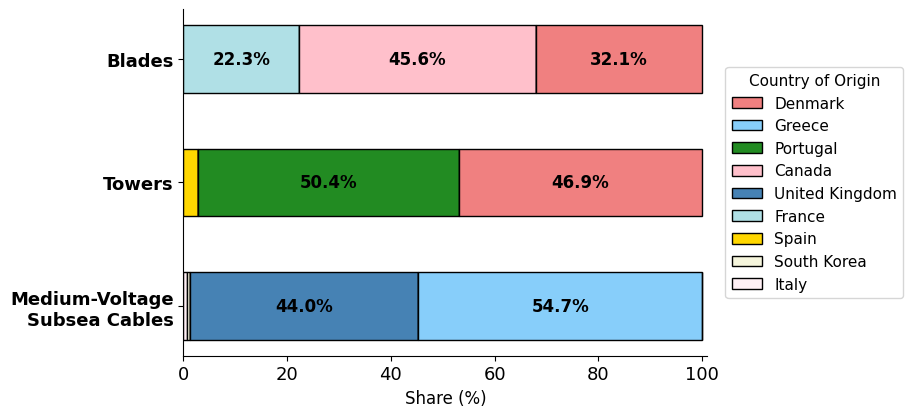

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Shared config ────────────────────────────────────────────────────────────

COLOR_MAPPING = {
    "Italy":          "lavenderblush",
    "Greece":         "lightskyblue",
    "France":         "powderblue",
    "Denmark":        "lightcoral",
    "Canada":         "pink",
    "Germany":        "darkorange",
    "Spain":          "gold",
    "Portugal":       "forestgreen",
    "Netherlands":    "lightgrey",
    "South Korea":    "beige",
    "Finland":        "tab:blue",
    "United Kingdom": "steelblue",
}
FALLBACK_COLOR  = "gray"
THRESHOLD_PCT   = 0
LABEL_FONTSIZE  = 12
TITLE_FONTSIZE  = 14
TICK_FONTSIZE   = 13
LEGEND_FONTSIZE = 11
BAR_HEIGHT      = 0.55


# ── Data loading ─────────────────────────────────────────────────────────────

def load_blades(csv_file):
    df = pd.read_csv(csv_file)
    df["Quantity of Blades"]                   = pd.to_numeric(df["Quantity of Blades"],                   errors="coerce")
    df["NREL category (turbine rating in MW)"]  = pd.to_numeric(df["NREL category (turbine rating in MW)"], errors="coerce")
    df = df.dropna(subset=["Quantity of Blades", "NREL category (turbine rating in MW)"])
    df["Blade MW"] = (df["Quantity of Blades"] / 3) * df["NREL category (turbine rating in MW)"]
    totals = df.groupby("Shipment Origin")["Blade MW"].sum()
    return (totals / totals.sum() * 100).rename("Blades")


def load_towers(csv_file):
    df = pd.read_csv(csv_file)
    df["Quantity of WTG Towers"]               = pd.to_numeric(df["Quantity of WTG Towers"],               errors="coerce")
    df["NREL category (turbine rating in MW)"]  = pd.to_numeric(df["NREL category (turbine rating in MW)"], errors="coerce")
    df = df.dropna(subset=["Quantity of WTG Towers", "NREL category (turbine rating in MW)"])
    df["Tower MW"] = df["Quantity of WTG Towers"] * df["NREL category (turbine rating in MW)"]
    totals = df.groupby("Shipment Origin")["Tower MW"].sum()
    return (totals / totals.sum() * 100).rename("Towers")


def load_array_cables(csv_file):
    df = pd.read_csv(csv_file)
    df = df[df["NREL category (Component category)"] == "Array Cable"]
    df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
    df = df.dropna(subset=["Quantity"])
    totals = df.groupby("Shipment Origin")["Quantity"].sum()
    return (totals / totals.sum() * 100).rename("Array Cables")


# ── Main plot ─────────────────────────────────────────────────────────────────

def plot_combined_stacked_bar(
    blades_csv="data/blades_panjiba_data.csv",
    towers_csv="data/towers_panjiba_data.csv",
    cables_csv="data/cables_panjiba_data.csv",
    out_path="figures/combined_imports_stacked_bar.svg",
):
    # Load all three series
    blades = load_blades(blades_csv)
    towers = load_towers(towers_csv)
    cables = load_array_cables(cables_csv).rename("Medium-Voltage\nSubsea Cables")

    # Combine into a single DataFrame; missing countries become 0
    df = pd.concat([blades, towers, cables], axis=1).fillna(0)

    # Identify "Others" countries (below threshold in ALL three components)
    small_mask = (df < THRESHOLD_PCT).all(axis=1)
    others     = df[small_mask].sum()
    df         = df[~small_mask]
    if others.sum() > 0:
        df.loc["Others"] = others

    # Sort rows by average share across components (largest on top)
    df["_avg"] = df.mean(axis=1)
    df = df.sort_values("_avg", ascending=True).drop(columns="_avg")

    countries  = df.index.tolist()
    components = ["Medium-Voltage\nSubsea Cables", "Towers", "Blades"]
    y_pos      = range(len(components))

    fig, ax = plt.subplots(figsize=(8, 4.5))

    for i, component in enumerate(components):
        left = 0.0
        for country in countries:
            val   = df.loc[country, component]
            color = COLOR_MAPPING.get(country, FALLBACK_COLOR)
            ax.barh(i, val, left=left, color=color, edgecolor="black",
                    height=BAR_HEIGHT)
            # Only label segments wide enough to be legible
            if val >= 4:
                ax.text(left + val / 2, i, f"{val:.1f}%",
                        va="center", ha="center",
                        fontsize=LABEL_FONTSIZE, fontweight="bold",
                        color="black")
            left += val

    # Axes formatting
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(components, fontsize=TICK_FONTSIZE, fontweight="bold")
    ax.set_xlabel("Share (%)", fontsize=LABEL_FONTSIZE)
    ax.set_xlim(0, 101)
    ax.tick_params(axis="x", labelsize=TICK_FONTSIZE)
    ax.spines[["top", "right"]].set_visible(False)
    #ax.set_title(
    #    "Offshore Wind Component Imports by Country of Origin (2015–current)\n"
    #    "Blades (MW), Towers (MW) & Medium-Voltage Subsea Cables (length) — each bar sums to 100%",
    #    fontsize=TITLE_FONTSIZE, fontweight="bold"
    #)

    # Legend — sorted to match bar order (largest share first)
    df_sort_desc = df.sort_values("_avg" if "_avg" in df.columns else "Blades", ascending=False)
    legend_countries = countries[::-1]  # reverse so biggest is at top of legend
    patches = [
        mpatches.Patch(
            facecolor=COLOR_MAPPING.get(c, FALLBACK_COLOR),
            edgecolor="black", label=c
        )
        for c in legend_countries
    ]
    ax.legend(
        handles=patches,
        title="Country of Origin",
        fontsize=LEGEND_FONTSIZE,
        title_fontsize=LEGEND_FONTSIZE,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        ncol=1,
        frameon=True,
    )

    fig.subplots_adjust(right=0.78)  # reserve space on the right for the legend
    import os
    os.makedirs("figures", exist_ok=True)
    fig.savefig(out_path, format="svg", dpi=300, bbox_inches="tight")
    print(f"Saved → {out_path}")
    plt.show()


if __name__ == "__main__":
    plot_combined_stacked_bar()

Saved → figures/cables_pie_chart.svg


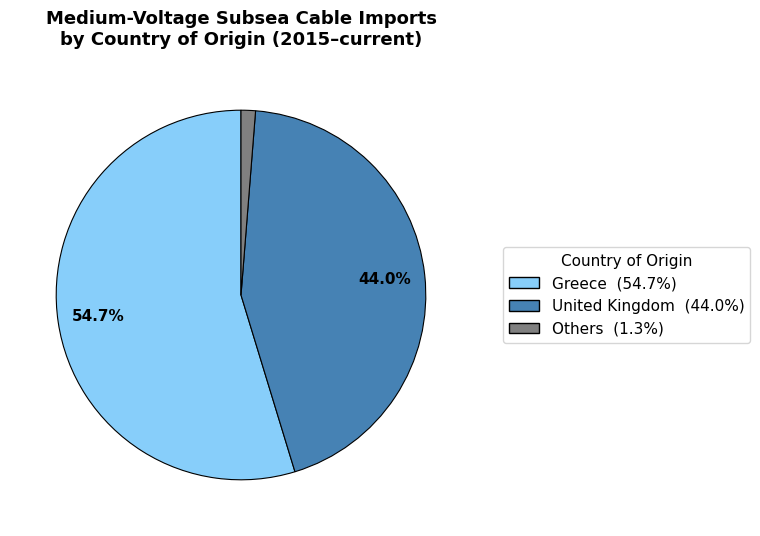

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Shared config ─────────────────────────────────────────────────────────────

COLOR_MAPPING = {
    "Italy":          "lavenderblush",
    "Greece":         "lightskyblue",
    "France":         "powderblue",
    "Denmark":        "lightcoral",
    "Canada":         "pink",
    "Germany":        "darkorange",
    "Spain":          "gold",
    "Portugal":       "forestgreen",
    "Netherlands":    "lightgrey",
    "South Korea":    "beige",
    "Finland":        "tab:blue",
    "United Kingdom": "steelblue",
}
FALLBACK_COLOR  = "gray"
THRESHOLD_PCT   = 2          # countries below this % are grouped into "Others"
LABEL_FONTSIZE  = 11
LEGEND_FONTSIZE = 11


# ── Data loading ──────────────────────────────────────────────────────────────

def load_array_cables(csv_file):
    df = pd.read_csv(csv_file)
    df = df[df["NREL category (Component category)"] == "Array Cable"]
    df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
    df = df.dropna(subset=["Quantity"])
    totals = df.groupby("Shipment Origin")["Quantity"].sum()
    pct = totals / totals.sum() * 100
    return pct.rename("Medium-Voltage Subsea Cables")


# ── Pie chart ─────────────────────────────────────────────────────────────────

def plot_cables_pie(
    cables_csv="data/cables_panjiba_data.csv",
    out_path="figures/cables_pie_chart.svg",
):
    series = load_array_cables(cables_csv)

    # Group small slices into "Others"
    small_mask = series < THRESHOLD_PCT
    others_val = series[small_mask].sum()
    series     = series[~small_mask].copy()
    if others_val > 0:
        series["Others"] = others_val

    series = series.sort_values(ascending=False)

    colors = [COLOR_MAPPING.get(c, FALLBACK_COLOR) for c in series.index]

    fig, ax = plt.subplots(figsize=(7, 6))

    wedges, texts, autotexts = ax.pie(
        series,
        labels=None,
        colors=colors,
        autopct=lambda p: f"{p:.1f}%" if p >= THRESHOLD_PCT else "",
        pctdistance=0.78,
        startangle=90,
        wedgeprops=dict(edgecolor="black", linewidth=0.8),
    )

    for at in autotexts:
        at.set_fontsize(LABEL_FONTSIZE)
        at.set_fontweight("bold")

    # Legend
    patches = [
        mpatches.Patch(
            facecolor=COLOR_MAPPING.get(c, FALLBACK_COLOR),
            edgecolor="black",
            label=f"{c}  ({series[c]:.1f}%)",
        )
        for c in series.index
    ]
    ax.legend(
        handles=patches,
        title="Country of Origin",
        fontsize=LEGEND_FONTSIZE,
        title_fontsize=LEGEND_FONTSIZE,
        loc="center left",
        bbox_to_anchor=(1.05, 0.5),
        frameon=True,
    )

    ax.set_title(
        "Medium-Voltage Subsea Cable Imports\nby Country of Origin (2015–current)",
        fontsize=13,
        fontweight="bold",
        pad=14,
    )

    os.makedirs("figures", exist_ok=True)
    fig.savefig(out_path, format="svg", dpi=300, bbox_inches="tight")
    print(f"Saved → {out_path}")
    plt.show()


if __name__ == "__main__":
    plot_cables_pie()